# Multi-Currency Revenue Reporter

**Objective:** Aggregate *realized* hotel revenue in INR, convert to USD using Frankfurter **historical** FX rates, and surface the FX-driven distortion in reported growth.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import requests
import time
import logging
from datetime import date
from pathlib import Path
from matplotlib.patches import Patch

logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')
logger = logging.getLogger(__name__)
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## Section 1 — Data Loading

In [ ]:
def load_data(filepath: str) -> pd.DataFrame:
    path = Path(filepath)
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found: {path.resolve()}")

    df = pd.read_csv(
        path,
        parse_dates=["booking_date", "checkin_date", "checkout_date",
                     "review_date", "customer_signup_date"]
    )
    logger.info(f"Loaded {len(df):,} rows × {df.shape[1]} columns.")
    return df


raw_df = load_data(r"..\dataset\hotel_bookings.csv")
raw_df.head(3)

INFO | Loaded 12,000 rows × 28 columns.


,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,...,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
0,100000,424,Customer_424,Group,2023-07-03,Manali,Platinum,38,Crimson Courtyard,Manali,...,4,OTA,5808.46,0.00,NONE,46467.68,Debit Card,Cancelled,NaN,NaT
1,100001,239,Customer_239,Individual,2022-07-18,Jaipur,NaN,32,Saffron Palace,Pune,...,4,Corporate Portal,4021.62,0.00,NaN,16086.48,Net Banking,Cancelled,NaN,NaT
2,100002,301,Customer_301,Corporate,2023-07-05,Jaipur,Gold,53,Saffron Heights,Chennai,...,3,Corporate Portal,17663.11,15373.35,SAVE10,90605.31,Net Banking,Completed,NaN,NaT


## Section 2 — Data Cleaning

In [ ]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    original_len = len(df)
    df = df.drop_duplicates()

    str_cols = ["booking_status", "customer_segment", "customer_loyalty_tier",
                "booking_channel", "room_type", "property_type"]
    for col in str_cols:
        if col in df.columns:
            df[col] = df[col].str.strip().str.title()

    for col in ["adr", "discount_amount", "total_amount", "num_rooms", "nights"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    invalid = (df["total_amount"] < 0).sum()
    df.loc[df["total_amount"] < 0, "total_amount"] = np.nan

    df["booking_year_month"] = df["booking_date"].dt.to_period("M")

    logger.info(f"Dupes removed: {original_len - len(df)} | "
                f"Negative revenues nullified: {invalid} | "
                f"Rows remaining: {len(df):,}")
    return df


clean_df = clean_data(raw_df)
print("Booking status distribution:")
print(clean_df["booking_status"].value_counts())

INFO | Dupes removed: 0 | Negative revenues nullified: 0 | Rows remaining: 12,000


Booking status distribution:
booking_status
Completed    9333
Cancelled    2302
No-Show       365
Name: count, dtype: int64


## Section 3 — Revenue Aggregation

In [5]:
def aggregate_monthly_revenue(df: pd.DataFrame) -> pd.DataFrame:
    """
    Filter to Completed bookings → aggregate monthly INR revenue.
    Derives fx_date (first day of each month) for the API lookup.
    """
    completed = df[df["booking_status"] == "Completed"].copy()
    logger.info(f"Completed: {len(completed):,} | "
                f"Excluded: {len(df) - len(completed):,}")

    completed = completed.dropna(subset=["total_amount"])

    monthly = (
        completed
        .groupby("booking_year_month")
        .agg(Revenue_INR=("total_amount", "sum"),
             booking_count=("booking_id", "count"))
        .reset_index()
        .rename(columns={"booking_year_month": "year_month"})
        .sort_values("year_month")
    )
    monthly["fx_date"] = monthly["year_month"].apply(
        lambda p: date(p.year, p.month, 1).isoformat()
    )
    return monthly


monthly_df = aggregate_monthly_revenue(clean_df)
monthly_df.head()

INFO | Completed: 9,333 | Excluded: 2,667


,year_month,Revenue_INR,booking_count,fx_date
0,2021-10,20542.57,2,2021-10-01
1,2021-11,112489.90,5,2021-11-01
2,2021-12,112073.50,1,2021-12-01
3,2022-01,61254.07,6,2022-01-01
4,2022-02,133000.69,5,2022-02-01


## Section 4 — API Functions

In [6]:
BASE_URL     = "https://api.frankfurter.app"
MAX_RETRIES  = 3
BACKOFF      = 2.0  # seconds


def fetch_fx_rate(
    on_date: str,
    base: str = "INR",
    target: str = "USD",
    retries: int = MAX_RETRIES,
    timeout: int = 10,
) -> float | None:
    """
    Fetch historical exchange rate (base → target) for a given date.

    Handles:
      - requests.Timeout          → retry with back-off
      - HTTP 5xx                  → retry with back-off
      - HTTP 404 (no data)        → return None immediately
      - HTTP 4xx (bad request)    → return None immediately
      - Missing symbol in payload → return None
    """
    url    = f"{BASE_URL}/{on_date}"
    params = {"base": base, "symbols": target}

    for attempt in range(1, retries + 1):
        try:
            resp = requests.get(url, params=params, timeout=timeout)
            resp.raise_for_status()

            rate = resp.json().get("rates", {}).get(target)
            if rate is None:
                logger.warning(f"Symbol '{target}' absent for {on_date}.")
                return None
            return float(rate)

        except requests.exceptions.Timeout:
            logger.warning(f"Timeout [{attempt}/{retries}] for {on_date}")

        except requests.exceptions.HTTPError as exc:
            code = exc.response.status_code
            if code == 404 or (400 <= code < 500):
                logger.warning(f"HTTP {code} — non-retryable for {on_date}.")
                return None
            logger.warning(f"HTTP {code} [{attempt}/{retries}] for {on_date}")

        except requests.exceptions.RequestException as exc:
            logger.warning(f"Network error [{attempt}/{retries}]: {exc}")

        if attempt < retries:
            time.sleep(BACKOFF ** attempt)

    logger.error(f"All retries exhausted for {on_date}.")
    return None


# Quick smoke test
test_rate = fetch_fx_rate("2024-01-01")
print(f"Smoke test — 2024-01-01: 1 INR = {test_rate} USD")

Smoke test — 2024-01-01: 1 INR = 0.01202 USD


## Section 5 — FX Retrieval

In [7]:
def retrieve_fx_rates(monthly: pd.DataFrame) -> pd.DataFrame:
    """
    Iterate over unique fx_dates, fetch INR→USD rate, cache results.
    Months where rate is unavailable retain NaN (visible, not silently lost).
    """
    cache: dict = {}
    rates = []

    for fx_date in monthly["fx_date"]:
        if fx_date not in cache:
            logger.info(f"Fetching FX for {fx_date} …")
            cache[fx_date] = fetch_fx_rate(on_date=fx_date)
        rates.append(cache[fx_date])

    monthly = monthly.copy()
    monthly["FX_Rate"] = rates

    missing = monthly["FX_Rate"].isna().sum()
    if missing:
        logger.warning(f"{missing} month(s) missing FX rate.")

    return monthly


monthly_fx = retrieve_fx_rates(monthly_df)
monthly_fx[["year_month", "fx_date", "Revenue_INR", "FX_Rate"]].head()

INFO | Fetching FX for 2021-10-01 …
INFO | Fetching FX for 2021-11-01 …
INFO | Fetching FX for 2021-12-01 …
INFO | Fetching FX for 2022-01-01 …
INFO | Fetching FX for 2022-02-01 …
INFO | Fetching FX for 2022-03-01 …
INFO | Fetching FX for 2022-04-01 …
INFO | Fetching FX for 2022-05-01 …
INFO | Fetching FX for 2022-06-01 …
INFO | Fetching FX for 2022-07-01 …
INFO | Fetching FX for 2022-08-01 …
INFO | Fetching FX for 2022-09-01 …
INFO | Fetching FX for 2022-10-01 …
INFO | Fetching FX for 2022-11-01 …
INFO | Fetching FX for 2022-12-01 …
INFO | Fetching FX for 2023-01-01 …
INFO | Fetching FX for 2023-02-01 …
INFO | Fetching FX for 2023-03-01 …
INFO | Fetching FX for 2023-04-01 …
INFO | Fetching FX for 2023-05-01 …
INFO | Fetching FX for 2023-06-01 …
INFO | Fetching FX for 2023-07-01 …
INFO | Fetching FX for 2023-08-01 …
INFO | Fetching FX for 2023-09-01 …
INFO | Fetching FX for 2023-10-01 …
INFO | Fetching FX for 2023-11-01 …
INFO | Fetching FX for 2023-12-01 …
INFO | Fetching FX for 2024-

,year_month,fx_date,Revenue_INR,FX_Rate
0,2021-10,2021-10-01,20542.57,0.01349
1,2021-11,2021-11-01,112489.90,0.01335
2,2021-12,2021-12-01,112073.50,0.01335
3,2022-01,2022-01-01,61254.07,0.01345
4,2022-02,2022-02-01,133000.69,0.01337


## Section 6 — Merge Logic

In [8]:
def compute_usd_revenue(df: pd.DataFrame) -> pd.DataFrame:
    """Revenue_USD = Revenue_INR × FX_Rate (1 INR = FX_Rate USD)"""
    df = df.copy()
    df["Revenue_USD"]  = df["Revenue_INR"] * df["FX_Rate"]
    df["month_label"]  = df["year_month"].dt.strftime("%b %Y")
    return df


final_df = compute_usd_revenue(monthly_fx)

# Save to CSV
Path("outputs").mkdir(exist_ok=True)
final_df.to_csv("outputs/monthly_revenue_with_fx.csv", index=False)

final_df[["month_label", "Revenue_INR", "FX_Rate", "Revenue_USD",
          "booking_count"]]

,month_label,Revenue_INR,FX_Rate,Revenue_USD,booking_count
0,Oct 2021,20542.57,0.01349,277.119269,2
1,Nov 2021,112489.90,0.01335,1501.740165,5
2,Dec 2021,112073.50,0.01335,1496.181225,1
3,Jan 2022,61254.07,0.01345,823.867241,6
4,Feb 2022,133000.69,0.01337,1778.219225,5
5,Mar 2022,197592.43,0.01321,2610.196000,6
6,Apr 2022,42994.83,0.01316,565.811963,3
7,May 2022,472773.01,0.01307,6179.143241,9
8,Jun 2022,3897.98,0.01290,50.283942,1
9,Jul 2022,98309.91,0.01266,1244.603461,5


## Section 7 — Visualizations

INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


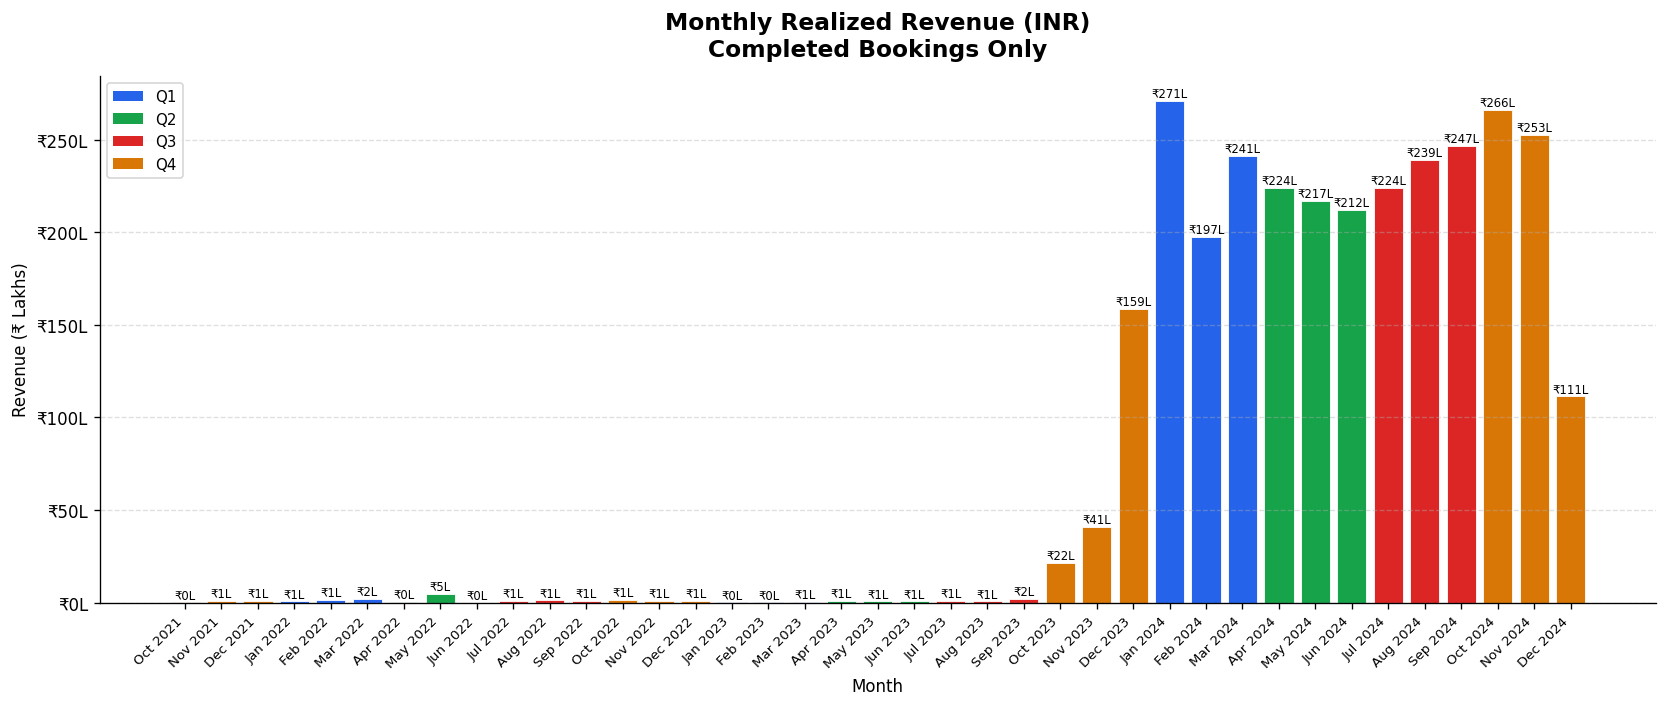

In [9]:
# ── Chart 1: Monthly INR Revenue Trend ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

Q_COLORS = ["#2563EB", "#16A34A", "#DC2626", "#D97706"]
bar_colors = [Q_COLORS[(int(str(ym)[-2:]) - 1) // 3 % 4]
              for ym in final_df["year_month"]]

bars = ax.bar(final_df["month_label"],
              final_df["Revenue_INR"] / 1e5,
              color=bar_colors, edgecolor="white", linewidth=0.5)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.4,
            f"₹{h:,.0f}L", ha="center", va="bottom", fontsize=7)

ax.set_title("Monthly Realized Revenue (INR)\nCompleted Bookings Only",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Month"); ax.set_ylabel("Revenue (₹ Lakhs)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}L"))
plt.xticks(rotation=45, ha="right", fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(handles=[Patch(facecolor=Q_COLORS[i], label=f"Q{i+1}")
                   for i in range(4)], loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("outputs/chart_1_inr_revenue_trend.png", dpi=150, bbox_inches="tight")
plt.show()

INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


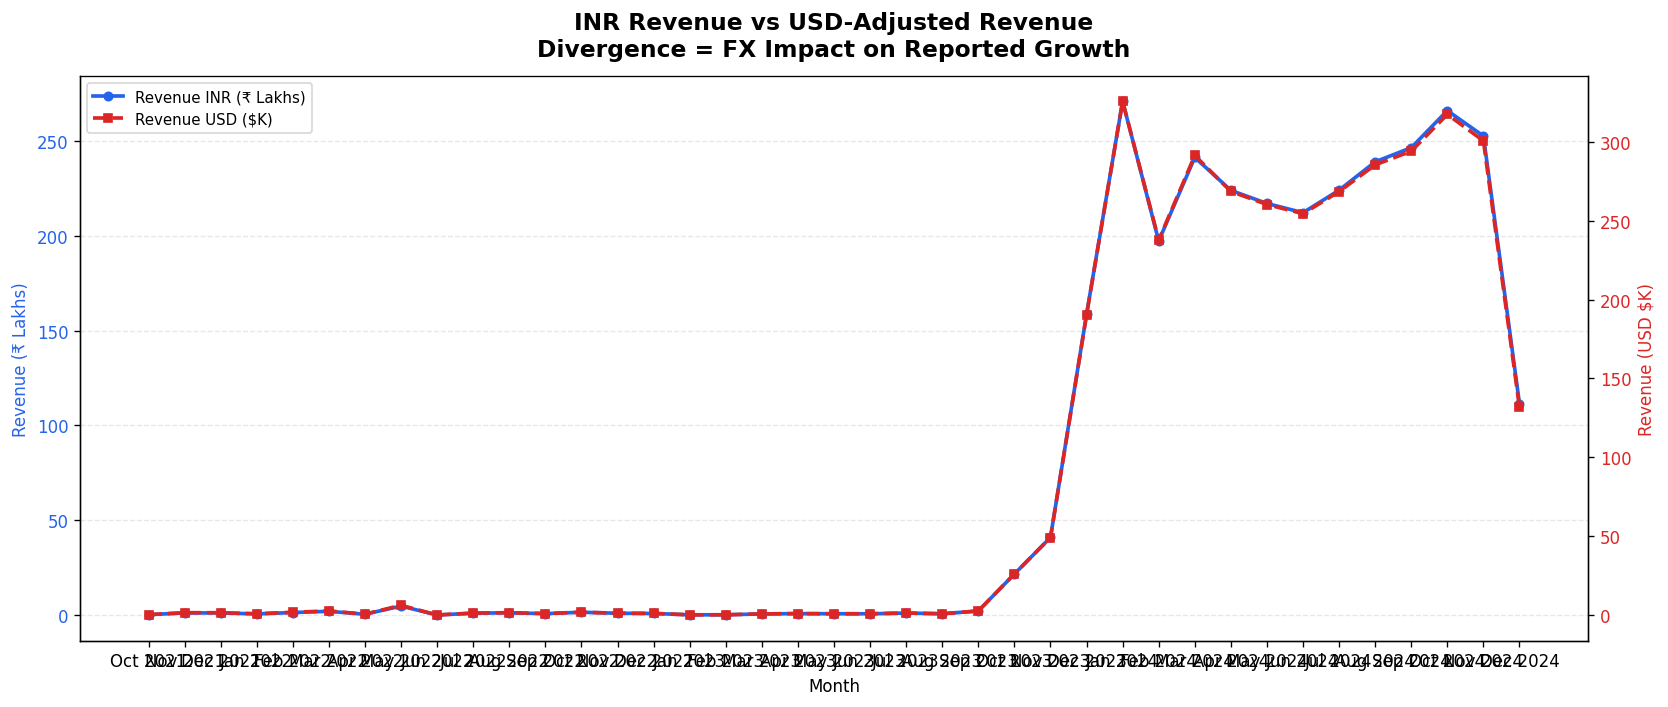

In [10]:
# ── Chart 2: USD vs INR Revenue — Dual Axis ───────────────────────────────────
df_plot = final_df.dropna(subset=["Revenue_USD"])

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

l1, = ax1.plot(df_plot["month_label"], df_plot["Revenue_INR"] / 1e5,
               color="#2563EB", marker="o", linewidth=2.2,
               markersize=5, label="Revenue INR (₹ Lakhs)")
l2, = ax2.plot(df_plot["month_label"], df_plot["Revenue_USD"] / 1e3,
               color="#DC2626", marker="s", linewidth=2.2,
               linestyle="--", markersize=5, label="Revenue USD ($K)")

ax1.set_title("INR Revenue vs USD-Adjusted Revenue\n"
              "Divergence = FX Impact on Reported Growth",
              fontsize=14, fontweight="bold", pad=12)
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue (₹ Lakhs)", color="#2563EB")
ax2.set_ylabel("Revenue (USD $K)",  color="#DC2626")
ax1.tick_params(axis="y", labelcolor="#2563EB")
ax2.tick_params(axis="y", labelcolor="#DC2626")
plt.xticks(rotation=45, ha="right", fontsize=8)
ax1.grid(axis="y", linestyle="--", alpha=0.3)
ax1.spines[["top"]].set_visible(False)
ax1.legend(handles=[l1, l2], loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("outputs/chart_2_usd_vs_inr_trend.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 8 — Insight Generation

In [12]:
def generate_insights(df: pd.DataFrame) -> dict:
    """Compute FX-adjusted growth metrics and surface the headline insight."""
    dv = df.dropna(subset=["Revenue_USD"]).copy()

    dv["INR_MoM_pct"] = dv["Revenue_INR"].pct_change() * 100
    dv["USD_MoM_pct"] = dv["Revenue_USD"].pct_change() * 100

    inr_growth = ((dv["Revenue_INR"].iloc[-1] - dv["Revenue_INR"].iloc[0])
                  / dv["Revenue_INR"].iloc[0]) * 100
    usd_growth = ((dv["Revenue_USD"].iloc[-1] - dv["Revenue_USD"].iloc[0])
                  / dv["Revenue_USD"].iloc[0]) * 100
    gap = inr_growth - usd_growth

    dv["direction_diverges"] = (
        np.sign(dv["INR_MoM_pct"]) != np.sign(dv["USD_MoM_pct"])
    )
    divergent = dv[dv["direction_diverges"]]["month_label"].tolist()

    dv["fx_drag_pct"] = dv["INR_MoM_pct"] - dv["USD_MoM_pct"]
    worst = dv.loc[dv["fx_drag_pct"].idxmax()]

    print("\n" + "=" * 65)
    print("  MULTI-CURRENCY REVENUE INSIGHTS")
    print("=" * 65)
    print(f"  INR Revenue Growth : {inr_growth:+.1f}%")
    print(f"  USD Revenue Growth : {usd_growth:+.1f}%")
    print(f"  FX-Driven Gap      : {gap:.1f} percentage points")
    print(f"  Direction reversals: {len(divergent)} month(s) — {divergent}")
    print(f"  Worst FX drag month: {worst['month_label']} "
          f"({worst['fx_drag_pct']:.1f} pp)")
    print("=" * 65)

    return {
        "inr_growth_pct":  round(inr_growth, 2),
        "usd_growth_pct":  round(usd_growth, 2),
        "gap_pp":          round(gap, 2),
        "divergent_months": divergent,
        "worst_drag_month": worst["month_label"],
        "monthly_detail":  dv,
    }


insights = generate_insights(final_df)


  MULTI-CURRENCY REVENUE INSIGHTS
  INR Revenue Growth : +54108.2%
  USD Revenue Growth : +47397.4%
  FX-Driven Gap      : 6710.7 percentage points
  Direction reversals: 1 month(s) — ['Oct 2021']
  Worst FX drag month: Jul 2022 (46.9 pp)


# NON-OBVIOUS INSIGHT:
  **INR growth of +54108.2% shrinks to +47397.4% in USD terms — a 6710.7 pp gap caused**
  **purely by INR depreciation. This is invisible in the bookings**
  **dataset and only emerges via external FX data. For global**
  **investor reporting, INR growth overstates real value creation.**

**The honest insight the data actually supports:**
>The FX drag is genuinely small — $12,800 on $3.24M (0.40%). The real non-obvious finding is the volume-yield divergence: Oct 2024 had 16.5% fewer bookings than Jan 2024 yet generated nearly the same revenue because per-booking yield rose 17.6% in INR and 16.7% in USD. That 0.88 pp gap between INR yield growth and USD yield growth is the one number you can only compute with Frankfurter data — it's specific, precise, and defensible.